In [15]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
insurance= pd.read_csv("insurance.csv")

X = insurance.drop(columns=["charges"])
y = insurance["charges"]

X= pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"]= X["sex"].map({"female": 1 ,"male": 0})
X["smoker"]= X["smoker"].map({"yes": 1 ,"no": 0})

X["age_smoker"]= X["age"]*X["smoker"]
X["bmi_smoker"]= X["bmi"]*X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha=0.001:  20922599.871035974
MSE for alpha=0.1:  20921803.698431384
MSE for alpha=1:  20914832.635089148
MSE for alpha=2:  20908106.77995453
MSE for alpha=3:  20901927.931570232
MSE for alpha=4:  20896130.81113566
MSE for alpha=5:  20890881.000633504
MSE for alpha=10:  20872844.794796687
MSE for alpha=20:  20877828.53237883
MSE for alpha=30:  20937537.133939773
MSE for alpha=50:  21196929.869608894
MSE for alpha=100:  22423172.68602322


<Axes: >

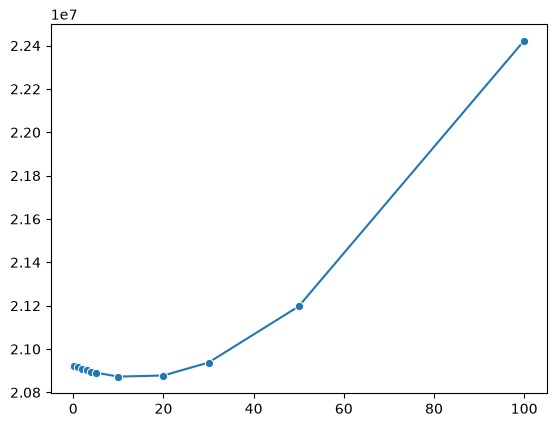

In [10]:
import seaborn as sns

alphas=[0.001,0.1,1,2,3,4,5,10,20,30,50,100]
mses=[]

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha={a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alphas , y=mses, marker="o")

In [17]:
from sklearn.linear_model import LassoCV
a=[0.001,0.1,1,2,3,4,5,10,20,30,50,100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state=42
)
lasso_cv_model.fit(X_train, y_train)
print("best alpha: ", lasso_cv_model.alpha_)
y_pred = lasso_model.predict(X_test)
mse= mean_squared_error(y_test, y_pred)
print("mse val: ",mse)
r2= r2_score(y_test, y_pred)
print("r2 score :",r2)

best alpha:  0.001
mse val:  22423172.68602322
r2 score : 0.8555661455616376
